In [3]:
df = pd.read_csv("C:/Users/AJAY/Desktop/STUDY MATERIAL/DSBDA/Social_Network_Ads.csv")

In [4]:
df

,UserID,Gender,Age,EstimatedSalary,Purchased
0,15121958,Female,49,54384,1
1,15671155,Female,21,127561,1
2,15131932,Female,47,62254,1
3,15365838,Female,54,36918,1
4,15259178,Female,40,100981,1
...,...,...,...,...,...
95,15315139,Male,35,120510,1
96,15171829,Male,57,69748,1
97,15271836,Male,18,20801,0
98,15438974,Female,28,44592,0


In [7]:
print(df.head())

     UserID  Gender  Age  EstimatedSalary  Purchased
0  15121958  Female   49            54384          1
1  15671155  Female   21           127561          1
2  15131932  Female   47            62254          1
3  15365838  Female   54            36918          1
4  15259178  Female   40           100981          1


In [8]:
print(df.shape)

(100, 5)


In [9]:
print(df.columns)

Index(['UserID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


In [10]:
print(df.dtypes)

UserID              int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object


In [11]:
print(df.isnull().sum())

UserID             0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [16]:
X = df[['Age', 'EstimatedSalary']]

In [17]:
Y = df['Purchased']

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0)

In [20]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
Y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, Y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 4  1]
 [ 1 19]]


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))

Accuracy: 0.92
Precision: 0.95
Recall: 0.95


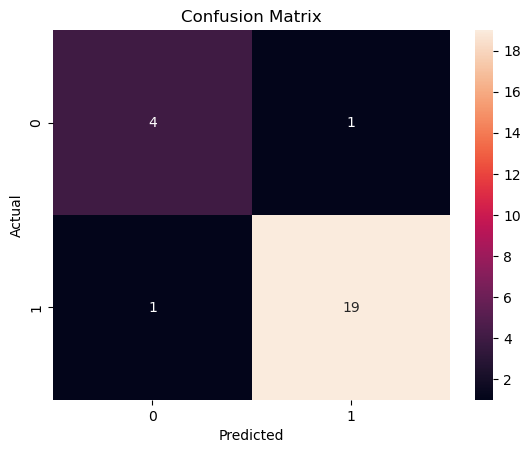

In [25]:
import seaborn as sns

sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()